In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
shanghai_data = pd.read_csv('../dataset/ShanghaiRailway/V_43.csv', header=None)
shanghai_weights = pd.read_csv('../dataset/ShanghaiRailway/W_43.csv', header=None)
shanghai_2d = shanghai_data.values

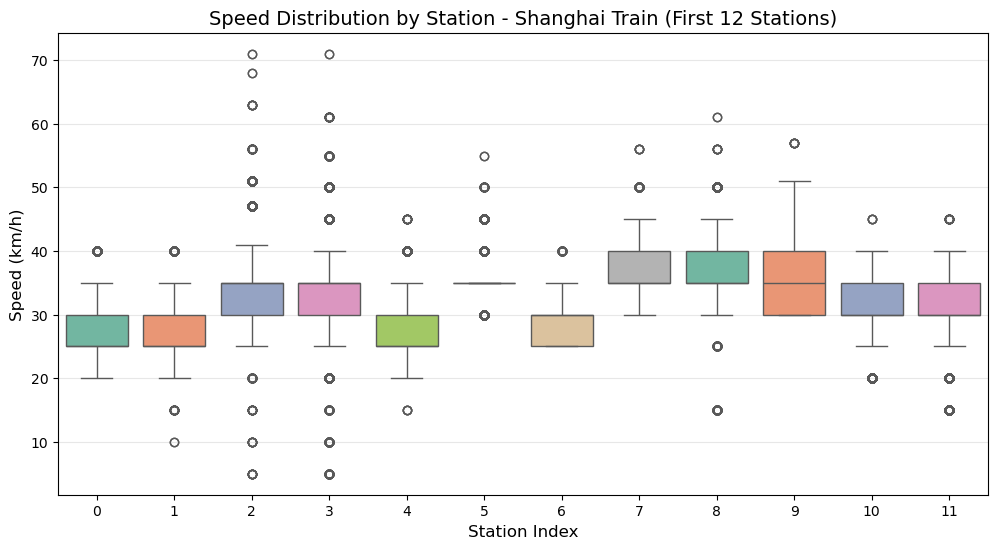

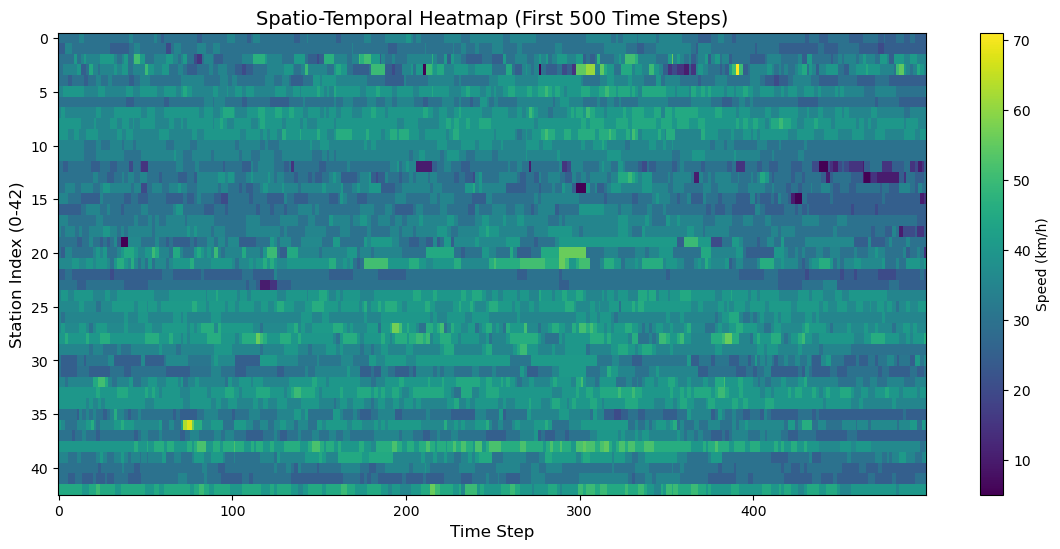

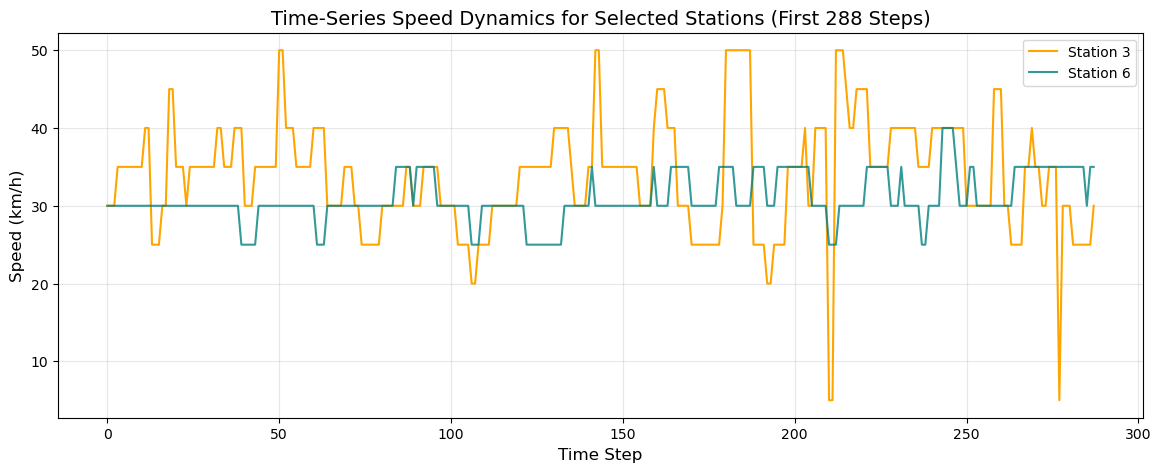

In [ ]:
plt.figure(figsize=(12, 6))
data_to_plot = shanghai_2d[:, :12] 

sns.boxplot(data=data_to_plot, palette="Set2")

plt.title('Speed Distribution by Station - Shanghai Train (First 12 Stations)', fontsize=14)
plt.xlabel('Station Index', fontsize=12)
plt.ylabel('Speed (km/h)', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')

# plt.savefig('../Results/Plots/Shanghai/shanghai_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()


plt.figure(figsize=(14, 6))

time_slice = 500
heatmap_data = shanghai_2d[:time_slice, :].T 

plt.imshow(heatmap_data, aspect='auto', cmap='viridis', interpolation='nearest')

plt.colorbar(label='Speed (km/h)')
plt.title(f'Spatio-Temporal Heatmap (First {time_slice} Time Steps)', fontsize=14)
plt.xlabel('Time Step', fontsize=12)
plt.ylabel('Station Index (0-42)', fontsize=12)

# plt.savefig('../Results/Plots/Shanghai/shanghai_st_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

plt.figure(figsize=(14, 5))

time_steps_to_show = 288 

plt.plot(shanghai_2d[:time_steps_to_show, 3], label='Station 3', color='orange', linewidth=1.5)
plt.plot(shanghai_2d[:time_steps_to_show, 6], label='Station 6', color='teal', linewidth=1.5, alpha=0.8)

plt.title(f'Time-Series Speed Dynamics for Selected Stations (First {time_steps_to_show} Steps)', fontsize=14)
plt.xlabel('Time Step', fontsize=12)
plt.ylabel('Speed (km/h)', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

# plt.savefig('../Results/Plots/Shanghai/shanghai_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

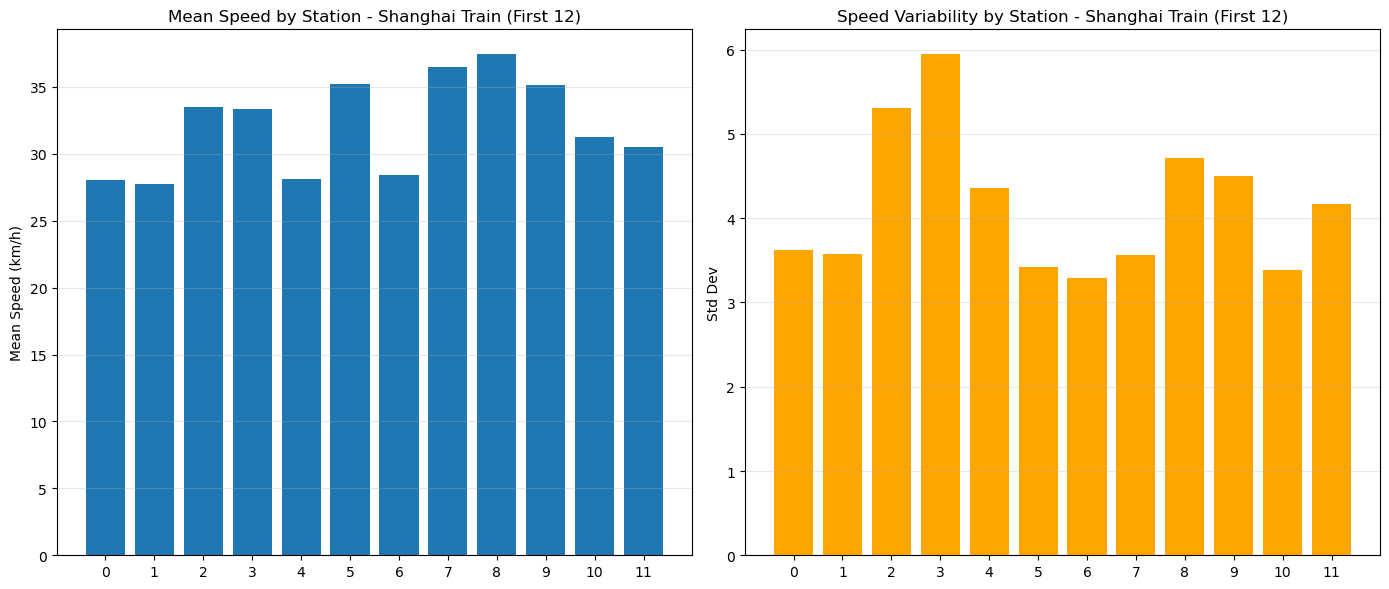

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

station_means = shanghai_2d.mean(axis=0)[:12]
axes[0].bar(range(len(station_means)), station_means)
axes[0].set_xticks(range(len(station_means)))
axes[0].set_xticklabels(range(len(station_means)), fontsize=10)
axes[0].set_ylabel('Mean Speed (km/h)')
axes[0].set_title('Mean Speed by Station - Shanghai Train (First 12)')
axes[0].grid(True, alpha=0.3, axis='y')

station_std = shanghai_2d.std(axis=0)[:12]
axes[1].bar(range(len(station_std)), station_std, color='orange')
axes[1].set_xticks(range(len(station_std)))
axes[1].set_xticklabels(range(len(station_std)), fontsize=10)
axes[1].set_ylabel('Std Dev')
axes[1].set_title('Speed Variability by Station - Shanghai Train (First 12)')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../Results/Plots/Shanghai/shanghai_eda_summary.png', dpi=150, bbox_inches='tight')
plt.show()

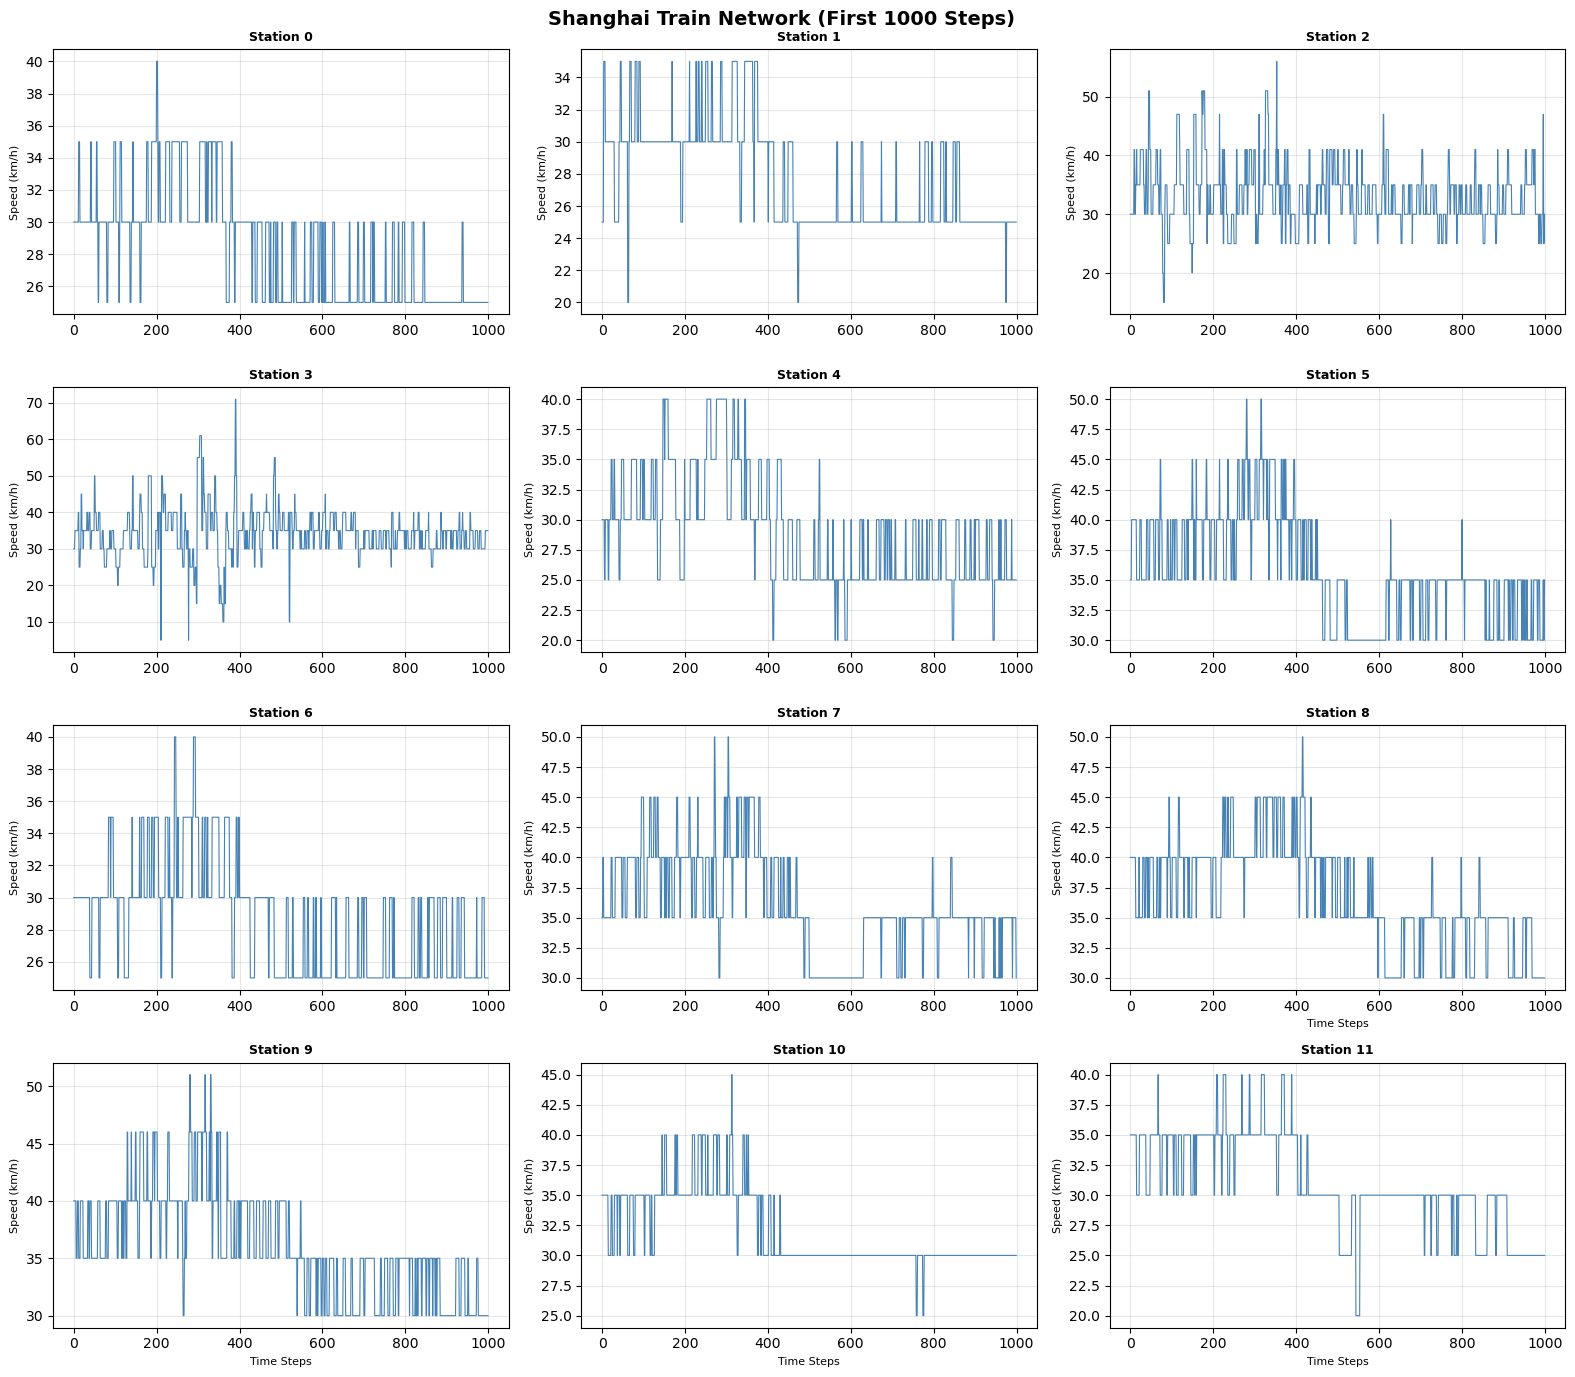

In [7]:
fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()

for i in range(min(12, shanghai_2d.shape[1])):
    axes[i].plot(shanghai_2d[:1000, i], linewidth=0.8, color='steelblue')
    axes[i].set_title(f'Station {i}', fontweight='bold', fontsize=9)
    axes[i].set_ylabel('Speed (km/h)', fontsize=8)
    axes[i].grid(True, alpha=0.3)
    if i >= 8:
        axes[i].set_xlabel('Time Steps', fontsize=8)

plt.suptitle('Shanghai Train Network (First 1000 Steps)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../Results/Plots/Shanghai/shanghai_timeseries_grid.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
stats = pd.DataFrame({
    'Station': range(shanghai_2d.shape[1]),
    'Mean': shanghai_2d.mean(axis=0),
    'Std': shanghai_2d.std(axis=0),
    'Min': shanghai_2d.min(axis=0),
    'Max': shanghai_2d.max(axis=0),
    'Median': np.median(shanghai_2d, axis=0)
})

stats

,Station,Mean,Std,Min,Max,Median
0,0,28.023626,3.619998,20,40,25.0
1,1,27.732671,3.579808,10,40,25.0
2,2,33.461404,5.306883,5,71,35.0
3,3,33.352335,5.943958,5,71,35.0
4,4,28.104882,4.362905,15,45,25.0
5,5,35.225327,3.422119,30,55,35.0
6,6,28.433027,3.285639,25,40,30.0
7,7,36.493218,3.567823,30,56,35.0
8,8,37.423214,4.709801,15,61,35.0
9,9,35.118070,4.502154,30,57,35.0
